# Numerical approach of gravitational wave polarization

This is my code where I will be computing TT h_ij from binary trajectories.

Notes:
*This code computes the grav. waves polarization from the numerical output given by the code
which ran a simulation of post-Newtonian binary orbits. 

In [239]:
#Section 1: Imports
#This part of the code imports all necessary libraries. 

import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Agg') 
import matplotlib.pyplot as plt
from scipy.signal import windows
import os

print("Starting code")



Starting code


In [326]:
#Section 2: Parameters
#This sets all constans I will use in the code and creates a parameter to call for the output csv file

CSV_PATH    = "1PN_output.csv"   # name of output CSV file
D_PC        = 100000000.0    # observer distance in parsecs
IOTA_DEG    = 0.0         # inclination angle
OUT_DIR     = "."         # folder where plots/CSVs will be saved
L           = 1        # meters

#don't know if this was necessary

G     = 6.67e-11 # m^3/kg s^-2
c     = 2.99e8   # m/s
M_sun = 1.98e30  # kg
pc   = 3.086e+16 # m


In [327]:
# Section 3: Extract simulation parameters from commented header
# This reads the commented lines at the top of the CSV and extracts values
# such as m1 and m2 automatically.

import re

params = {}

with open(CSV_PATH, "r") as f:
    for line in f:
        line = line.strip()

        # Stop once actual CSV data begins
        if not line.startswith("#"):
            break

        # Match lines like:
        # m1=1
        # m2=1.65e-07
        match = re.match(r"#\s*([A-Za-z0-9_]+)\s*=\s*(.+)", line)

        if match:
            key = match.group(1)
            value = match.group(2)

            # Convert numerical values to float when possible
            try:
                value = float(value)
            except ValueError:
                pass

            params[key] = value

# Extract masses
M1 = params.get("m1")
M2 = params.get("m2")

print(f"m1 = {M1}")
print(f"m2 = {M2}")

m1 = 1000000.0
m2 = 100.0


In [328]:
# Section 4: Load csv 
# csv is loaded into Pandas, also added a little trap for the code to double check that 
# all the necessary columns are in the csv and let me know if their are not, and exactly 
# which ones are missing. 
# also let's meknow how many rows were loaded

print("Loading CSV")
df = pd.read_csv(CSV_PATH, comment="#")

required = ["t","l","u","R","v","phi","x","y","Ixx","Ixy","Iyy","Id_xx","Id_xy","Id_yy","Idd_xx","Idd_xy","Idd_yy"]
missing = [col for col in required if col not in df.columns]
if missing:
    raise ValueError(f"This column is missing in CSV: {missing}")

print(f"  Number of rows: {len(df)}")


Loading CSV
  Number of rows: 769091


In [329]:
# Section 5: Unit conversion
# after defining the conversions, I applied them to every column.
# the reduced mass is also computed here.
# print the values.

m1_si = M1 * M_sun 
m2_si = M2 * M_sun 
M_tot = m1_si + m2_si
#L = G / (c*c)

'''t_unit = G * M_tot / c**3    
'''
x_unit = G * M_tot / c**2    
v_unit = c                   

df_si = df.copy()
'''df_si["t"]    *= t_unit'''

mu   = (m1_si * m2_si) / (m1_si + m2_si)   # reduced mass [kg]
D    = D_PC * pc                           # distance [m]
iota = np.radians(IOTA_DEG)

print(f"  m1 = {m1_si:.3e} kg,  m2 = {m2_si:.3e} kg")
print(f"  Reduced mass mu = {mu:.3e} kg")
print(f"  Distance D = {D:.3e} m  ({D_PC} pc)")
print(f"  Inclination iota = {IOTA_DEG}°")


  m1 = 1.980e+36 kg,  m2 = 1.980e+32 kg
  Reduced mass mu = 1.980e+32 kg
  Distance D = 3.086e+24 m  (100000000.0 pc)
  Inclination iota = 0.0°


In [330]:
# Section 6: Extract Arrays

t   = df["t"].values

Ixx = df_si["Ixx"].values
Ixy = df_si["Ixy"].values
Iyy = df_si["Iyy"].values

Id_xx = df_si["Id_xx"].values
Id_xy = df_si["Id_xy"].values
Id_yy = df_si["Id_yy"].values

sIdd_xx = df_si["Idd_xx"].values
sIdd_xy = df_si["Idd_xy"].values
sIdd_yy = df_si["Idd_yy"].values



In [331]:
# Section 7: Mass moment and second derivative 
#the grav. wave depends on the first mass moment, which for two-point mass systems 
#simplify to the expression with reduced mass.

# print("Computing mass moment")

# # Defining the derivative function

def deriv(f, t):
     n  = len(f)
     fd = np.zeros(n)
     for i in range(1, n - 1):
         dt_p = t[i+1] - t[i]
         dt_m = t[i]   - t[i-1]
         fd[i] = (f[i+1] - f[i-1]) / (dt_p + dt_m)
     fd[0]  = fd[1]
     fd[-1] = fd[-2]
     return fd

 # Creating the second derivative of I
rId_xx = deriv(Ixx, t)
rId_xy = deriv(Ixy, t)
rId_yy = deriv(Iyy, t)

rIdd_xx = deriv(rId_xx, t)
rIdd_xy = deriv(rId_xy, t)
rIdd_yy = deriv(rId_yy, t)



In [332]:
units_rIdd_xx = (rIdd_xx * c**4 * L) / G
units_rIdd_xy = (rIdd_xy * c**4 * L) / G
units_rIdd_yy = (rIdd_yy * c**4 * L) / G

  h+  peak amplitude : 8.5641e-10
  hx  peak amplitude : 8.6268e-10
Saved: h_time_domain.png


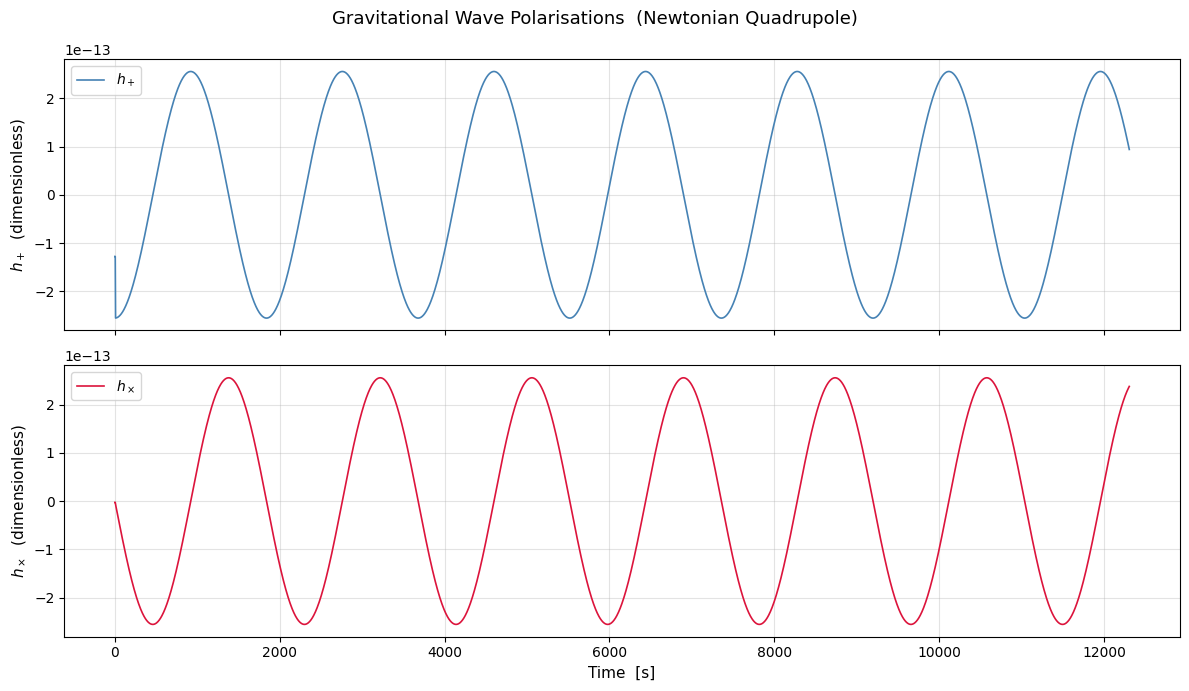

In [333]:
# Section 8: Actual computing of h+ and hx 
# grav. waves are given by TT projection of quadrupole formula 
#this is the computing of the actual h+ and hx

prefactor = 2.0 * G / (c**4 * D)
h_plus    = prefactor * ((units_rIdd_xx - units_rIdd_yy) / 2.0) 
h_cross   = prefactor * units_rIdd_xy 

print(f"  h+  peak amplitude : {np.max(np.abs(h_plus)):.4e}")
print(f"  hx  peak amplitude : {np.max(np.abs(h_cross)):.4e}")


# PLOT 2 — TIME-DOMAIN WAVEFORMS
# this is the time-domain waveform plots (amplitude of h+ and hx vs time)
# saved as h_time_domain.png

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Gravitational Wave Polarisations  (Newtonian Quadrupole)", fontsize=13)

axes[0].plot(t[:3000], h_plus[:3000],  color="steelblue", lw=1.2, label=r"$h_+$")
axes[0].set_ylabel(r"$h_+$  (dimensionless)", fontsize=11)
axes[0].legend(fontsize=10);  axes[0].grid(True, alpha=0.35)

axes[1].plot(t[:3000], h_cross[:3000], color="crimson",   lw=1.2, label=r"$h_\times$")
axes[1].set_ylabel(r"$h_\times$  (dimensionless)", fontsize=11)
axes[1].set_xlabel("Time  [s]", fontsize=11)
axes[1].legend(fontsize=10);  axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "h_time_domain.png"), dpi=150)
#plt.show()  # disabled: using Agg backend, plots saved to files
print("Saved: h_time_domain.png")

In [334]:
# Section 9: Mass moment and second derivative 
#the grav. wave depends on the first mass moment, which for two-point mass systems 
#simplify to the expression with reduced mass.

# print("Computing mass moment")

# # Defining the derivative function

def deriv(f, t):
     n  = len(f)
     fd = np.zeros(n)
     for i in range(1, n - 1):
         dt_p = t[i+1] - t[i]
         dt_m = t[i]   - t[i-1]
         fd[i] = (f[i+1] - f[i-1]) / (dt_p + dt_m)
     fd[0]  = fd[1]
     fd[-1] = fd[-2]
     return fd

 # Creating the second derivative of I
Idd_xx = deriv(Id_xx, t)
Idd_xy = deriv(Id_xy, t)
Idd_yy = deriv(Id_yy, t)

In [335]:
units_Idd_xx = (Idd_xx * c**4 * L) / G
units_Idd_xy = (Idd_xy * c**4 * L) / G
units_Idd_yy = (Idd_yy * c**4 * L) / G

  h+  peak amplitude : 4.5461e-09
  hx  peak amplitude : 4.5166e-09
Saved: h_time_domain.png


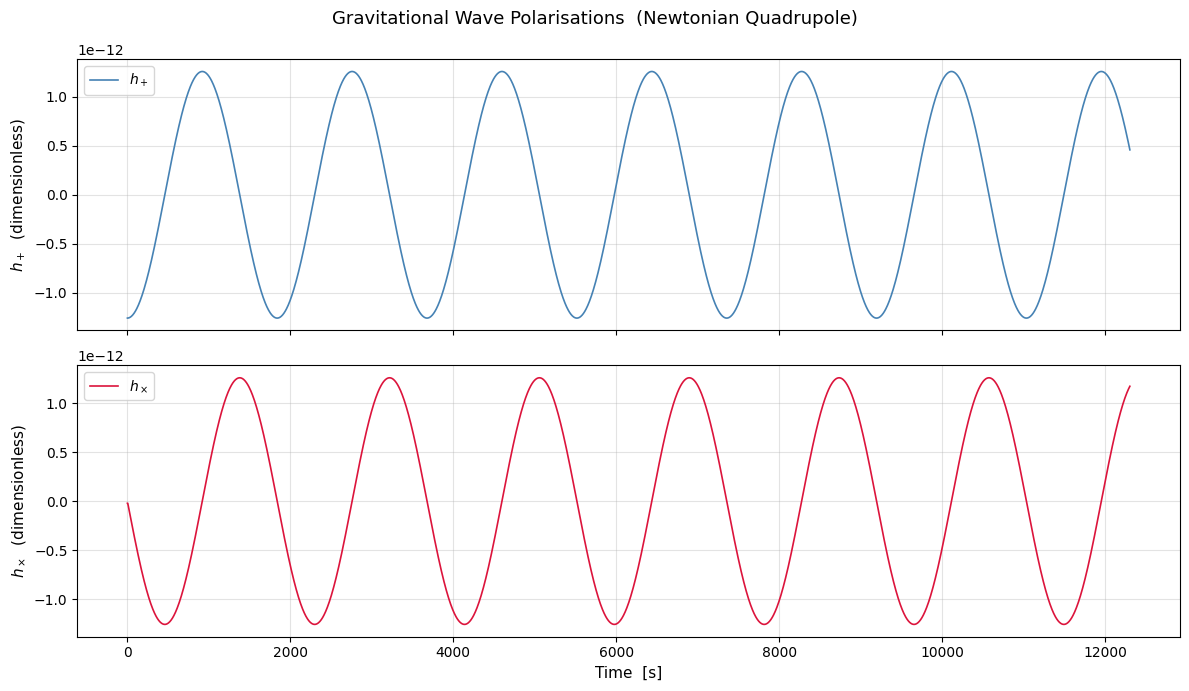

In [336]:
# Section 10: Actual computing of h+ and hx 
# grav. waves are given by TT projection of quadrupole formula 
#this is the computing of the actual h+ and hx

prefactor = 2.0 * G / (c**4 * D)
h_plus    = prefactor * ((units_Idd_xx - units_Idd_yy) / 2.0) 
h_cross   = prefactor * units_Idd_xy 

print(f"  h+  peak amplitude : {np.max(np.abs(h_plus)):.4e}")
print(f"  hx  peak amplitude : {np.max(np.abs(h_cross)):.4e}")

# PLOT 2 — TIME-DOMAIN WAVEFORMS
# this is the time-domain waveform plots (amplitude of h+ and hx vs time)
# saved as h_time_domain.png

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Gravitational Wave Polarisations  (Newtonian Quadrupole)", fontsize=13)

axes[0].plot(t[:3000], h_plus[:3000],  color="steelblue", lw=1.2, label=r"$h_+$")
axes[0].set_ylabel(r"$h_+$  (dimensionless)", fontsize=11)
axes[0].legend(fontsize=10);  axes[0].grid(True, alpha=0.35)

axes[1].plot(t[:3000], h_cross[:3000], color="crimson",   lw=1.2, label=r"$h_\times$")
axes[1].set_ylabel(r"$h_\times$  (dimensionless)", fontsize=11)
axes[1].set_xlabel("Time  [s]", fontsize=11)
axes[1].legend(fontsize=10);  axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "h_time_domain.png"), dpi=150)
#plt.show()  # disabled: using Agg backend, plots saved to files
print("Saved: h_time_domain.png")

In [90]:
# Section 11: Save outputs as .csv files

pd.DataFrame({"time": t, "h_plus": h_plus, "h_cross": h_cross})\
  .to_csv(os.path.join(OUT_DIR, "gw_polarisations.csv"), index=False)
print("Saved: gw_polarisations.csv")


print("\nAll done!")

Saved: gw_polarisations.csv

All done!
